# Lightweight Grid Calibration Notebook

This notebook compares synthetic and real grids using the exported CSV metrics only.

It keeps status-stratified diagnostics at the top as a check, but uses the full synthetic export for the main representativeness comparison. Normalized Wasserstein distance is the primary score, and feeder count is shown together with buildings per feeder.

In [ ]:
import importlib
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

comparison_helpers = importlib.import_module("pylovo.analysis.comparison_helpers")
comparison_helpers = importlib.reload(comparison_helpers)
comparison_notebook = importlib.import_module("validations.grid_comparison.comparison_notebook")
comparison_notebook = importlib.reload(comparison_notebook)

DEFAULT_LABELS = comparison_notebook.DEFAULT_LABELS
DEFAULT_METRICS = comparison_notebook.DEFAULT_METRICS
load_and_render_overview = comparison_notebook.load_and_render_overview
plot_boxplot_overview = comparison_notebook.plot_boxplot_overview
plot_metric_kde_diagonal = comparison_notebook.plot_metric_kde_diagonal
plot_scenario_kde_diagonal = comparison_notebook.plot_scenario_kde_diagonal
show_cable_type_comparison = comparison_notebook.show_cable_type_comparison
show_distribution_selector = comparison_notebook.show_distribution_selector
show_wasserstein_summary = comparison_notebook.show_wasserstein_summary

METRICS_DIR = project_root / "validations" / "metrics"
SYNTHETIC_METRICS_FILE = "synthetic_grid_metrics_s1dvgf.csv"
REAL_METRICS_FILE = "real_grid_metrics_s1dvgf.csv"
METRICS = list(DEFAULT_METRICS)
LABELS = dict(DEFAULT_LABELS)
PALETTE = {"Synthetic": "steelblue", "Real": "crimson"}
MIN_CABLE_SEGMENTS = 100
PLZ = 91301
REAL_GRID_DIR = None

In [ ]:
notebook_data = load_and_render_overview(
    metrics_dir=METRICS_DIR,
    metrics=METRICS,
    labels=LABELS,
    synthetic_metrics_filename=SYNTHETIC_METRICS_FILE,
    real_metrics_filename=REAL_METRICS_FILE,
)

### Data Inputs

,source,path,rows
0,Synthetic,/home/breveron/git/github/pylovo/validations/m...,102
1,Real,/home/breveron/git/github/pylovo/validations/m...,85


### Status-Stratified Diagnostics

,power_flow_status,count
0,converged,47
1,voltage_violation,55


,power_flow_status,synthetic_n,real_n,mean_normalized_wasserstein,median_normalized_wasserstein,worst_metric,worst_normalized_wasserstein
0,converged,47,85,0.5104,0.5136,graph_resistance,0.6489
1,voltage_violation,55,85,0.5424,0.5898,feeder_lines,0.6822


### Primary Wasserstein Score

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,transformer_mva,102,85,0.0171,0.0745,excellent
1,max_trafo_distance,102,85,0.1013,0.2297,good
2,graph_length,102,85,0.3688,0.2402,good
3,avg_trafo_distance,102,85,0.0579,0.2407,good
4,graph_resistance,102,85,0.0815,0.2517,acceptable
5,feeder_lines,102,85,1.5843,0.2641,acceptable


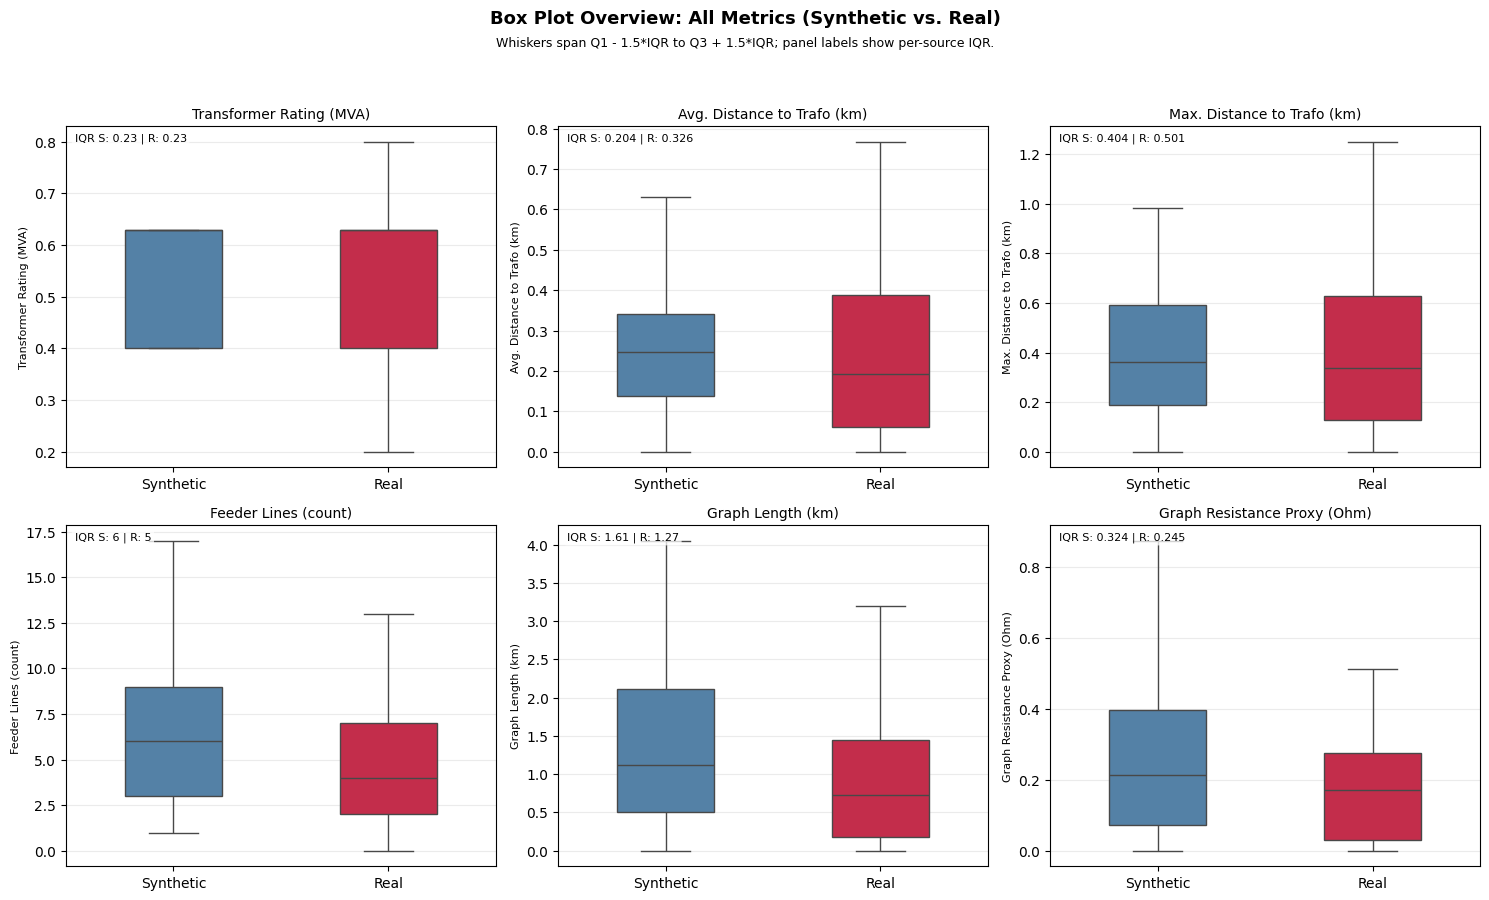

In [ ]:
_ = plot_boxplot_overview(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    title="Box Plot Overview: All Metrics (Synthetic vs. Real)",
)

In [ ]:
show_distribution_selector(
    notebook_data.df_all,
    notebook_data.metrics,
    notebook_data.labels,
    plot_type="box",
    height=520,
)

interactive(children=(Dropdown(description='Parameter:', options=('transformer_mva', 'avg_trafo_distance', 'ma…

In [ ]:
show_distribution_selector(
    notebook_data.df_all,
    notebook_data.metrics,
    notebook_data.labels,
    plot_type="violin",
    height=550,
    width=700,
)

interactive(children=(Dropdown(description='Parameter:', options=('transformer_mva', 'avg_trafo_distance', 'ma…

In [ ]:
_ = show_cable_type_comparison(
    PLZ,
    real_grid_dir=REAL_GRID_DIR,
    min_segment_count=MIN_CABLE_SEGMENTS,
 )

Showing cable types with more than 100 weighted line segments across real and synthetic grids. `segment_count` counts every in-service `net.line` segment between modeled nodes; parallel circuits contribute via their `parallel` multiplier, so this is not a whole-feeder count.

,std_type,source,segment_count,total_length_km,impedance_ohm_per_km
0,NS-Leitungstyp_fiktiv,Real,126.0,1.223,0.0000
1,NYY-J 3x150SM 0.6/1kV,Real,1532.0,40.338,0.1453
2,NYY-J 4x120,Real,609.0,18.340,0.1735
3,NAYY 4x185SE 0.6/1kV,Real,916.0,30.449,0.1836
4,NYY-J 3x95SM 0.6/1kV,Real,743.0,18.765,0.2080
5,NAYBY 4x150sm 0.6/1kV,Real,120.0,2.758,0.2197
6,NAYY 4x150SE 0.6/1kV,Real,457.0,11.690,0.2218
7,NAYY 4x120SE 0.6/1kV,Real,293.0,8.619,0.2666
8,NYY-J 3x70SM 0.6/1kV,Real,1547.0,32.890,0.2788
9,NAYY 4x95SE 0.6/1kV,Real,123.0,5.336,0.3311


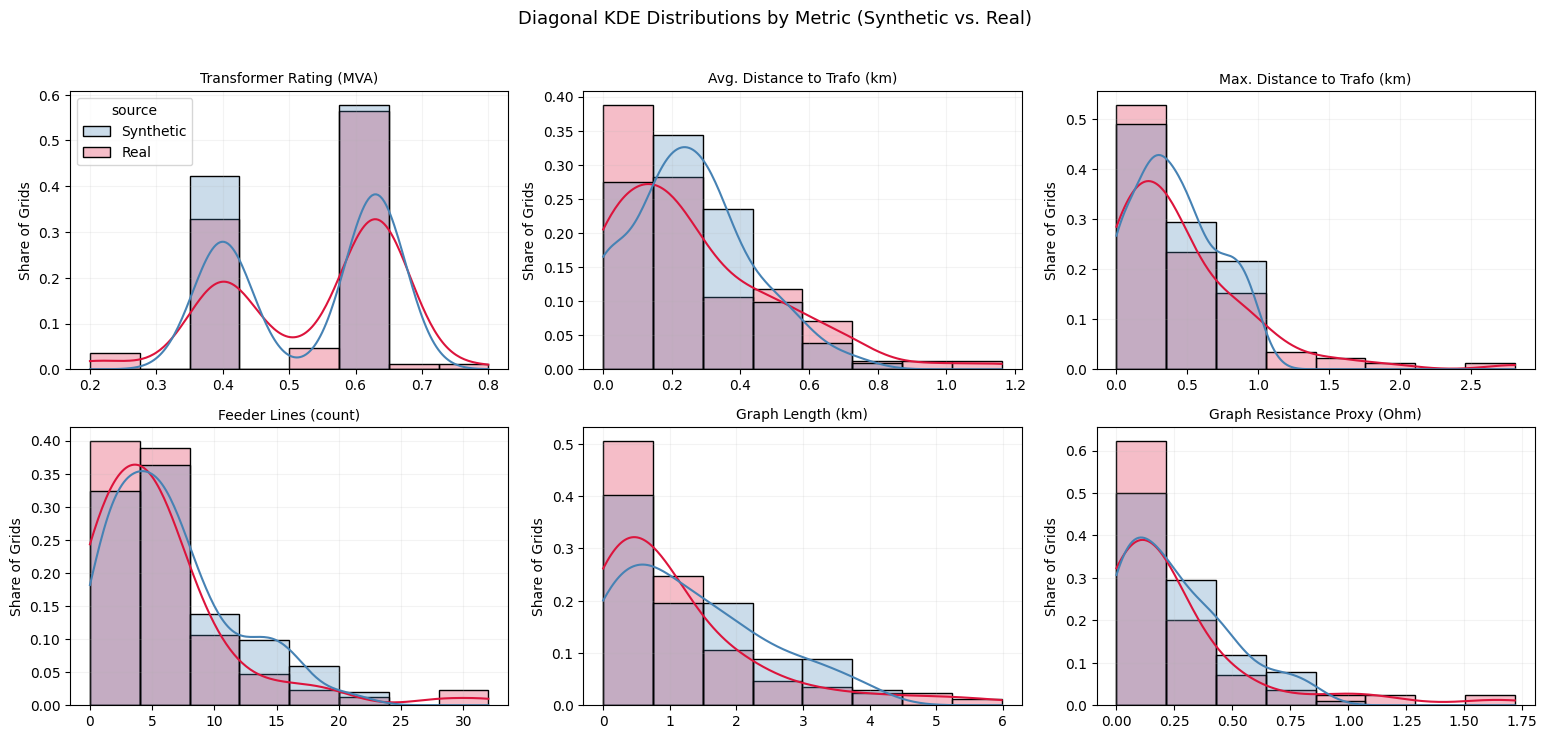

In [ ]:
_ = plot_metric_kde_diagonal(
    notebook_data.df_all,
    notebook_data.metrics,
    labels=notebook_data.labels,
    palette=PALETTE,
    show_hist_bars=True,
    bins=8,
    n_cols=3,
    title="Diagonal KDE Distributions by Metric (Synthetic vs. Real)",
    upper_percentile=KDE_UPPER_PERCENTILE if "KDE_UPPER_PERCENTILE" in globals() else None,
    clip_nonnegative=True,
)

### Scenario KDE Comparison

KDE-only comparison of all four synthetic scenario distributions against one real reference distribution.


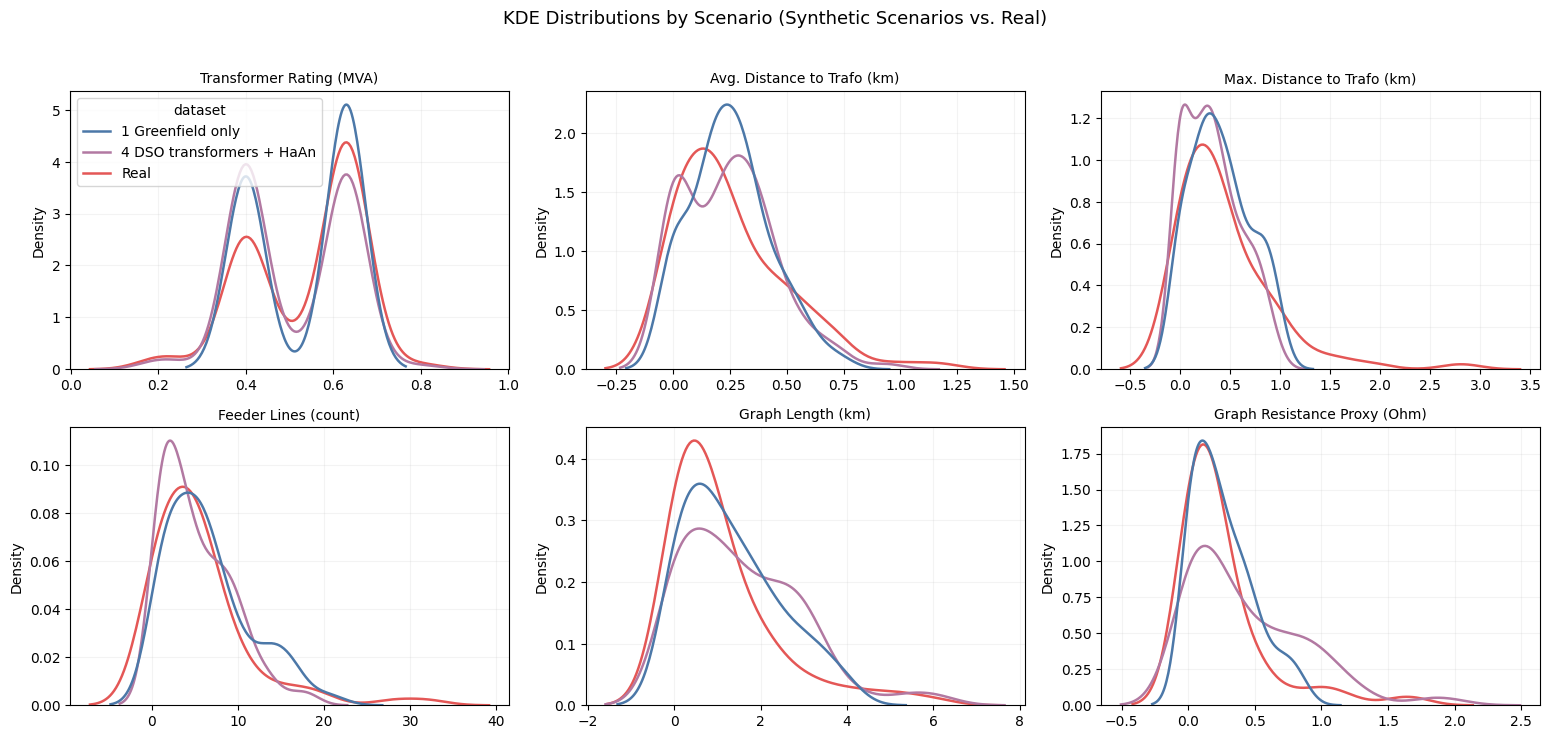

In [ ]:
SCENARIO_METRIC_FILES = {
    "1 Greenfield only": "synthetic_grid_metrics_s1dvgf.csv",
    # "2 Open brownfield": "synthetic_grid_metrics_s2dvop.csv",
    # "3 DSO transformers": "synthetic_grid_metrics_s3dsoimp.csv",
    "4 DSO transformers + HaAn": "synthetic_grid_metrics_s4ha150.csv",
}

# Set to 0.99 or 0.95 to focus the KDE view on the main distribution.
KDE_UPPER_PERCENTILE = None

SCENARIO_PALETTE = {
    "1 Greenfield only": "#4C78A8",
    # "2 Open brownfield": "#F58518",
    # "3 DSO transformers": "#54A24B",
    "4 DSO transformers + HaAn": "#B279A2",
    "Real": "#E45756",
}

_ = plot_scenario_kde_diagonal(
    SCENARIO_METRIC_FILES,
    METRICS,
    metrics_dir=METRICS_DIR,
    real_metrics_filename="real_grid_metrics_s1dvgf.csv",
    labels=LABELS,
    palette=SCENARIO_PALETTE,
    n_cols=3,
    title="KDE Distributions by Scenario (Synthetic Scenarios vs. Real)",
    upper_percentile=KDE_UPPER_PERCENTILE,
    clip_nonnegative=True,
)
